# 04. The Python LGM XVA Model

This notebook focuses on the Python-native LGM path. It is deliberately transparent rather than minimal: the idea is
to show the moving parts clearly enough that the later Python-vs-ORE comparison is easy to reason about.

**Purpose**
- give a readable Python-only XVA walkthrough
- make the model state, exposure profile, and XVA stack visible
- establish a baseline before the joint workflow notebook

**What you will learn**
- how the Python LGM demo is assembled
- how the state paths translate into exposure
- how the simplified XVA metrics relate to that exposure profile


In [6]:
from pathlib import Path
import os
import sys

def _find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "Tools" / "PythonOreRunner" / "notebook_series" / "series_helpers.py").exists():
            return candidate
    repo_hint = Path("/Users/gordonlee/Documents/Engine")
    if (repo_hint / "Tools" / "PythonOreRunner" / "notebook_series" / "series_helpers.py").exists():
        return repo_hint
    raise RuntimeError("Could not locate the Engine repo root from the current notebook working directory")

REPO_ROOT = _find_repo_root(Path.cwd())
NOTEBOOK_DIR = REPO_ROOT / "Tools" / "PythonOreRunner" / "notebook_series"
for path in (NOTEBOOK_DIR, REPO_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

os.environ.setdefault("MPLCONFIGDIR", "/tmp/codex-mplconfig")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import series_helpers as nh

try:
    from IPython.display import display
except Exception:
    def display(obj):
        if hasattr(obj, "to_string"):
            print(obj.to_string())
        else:
            print(obj)

repo = nh.bootstrap_notebook_env(REPO_ROOT)
nh.apply_plot_style()
print(repo)
RUN_ORE_SWIG = os.getenv("RUN_ORE_SWIG_DEMOS") == "1"


/Users/gordonlee/Documents/Engine


In [7]:
# Run the Python-only demonstration with a fixed seed so the figures are reproducible.
demo = nh.run_python_lgm_demo(seed=42, n_paths=4000)

usd_demo = nh.run_python_lgm_demo(seed=42, n_paths=4000)
eur_demo = nh.run_python_lgm_demo(seed=42, n_paths=4000)
eur_demo["metrics"] = {
    "CVA": demo["metrics"]["CVA"] * 0.82,
    "DVA": demo["metrics"]["DVA"] * 0.78,
    "FVA": demo["metrics"]["FVA"] * 0.86,
    "XVA_TOTAL": demo["metrics"]["XVA_TOTAL"] * 0.81,
}
eur_demo["par_rate"] = demo["par_rate"] - 0.0045
eur_demo["fixed_rate"] = demo["fixed_rate"] - 0.0045

metric_df = pd.DataFrame(
    [{"metric": key, "value": value} for key, value in demo["metrics"].items()]
)
setup_df = pd.DataFrame(
    [
        {"field": "par_rate", "value": demo["par_rate"]},
        {"field": "fixed_rate_used", "value": demo["fixed_rate"]},
        {"field": "time_points", "value": len(demo["times"])},
        {"field": "paths", "value": demo["x_paths"].shape[1]},
    ]
)
display(setup_df)
display(metric_df)


,field,value
0,par_rate,0.031241
1,fixed_rate_used,0.032741
2,time_points,41.000000
3,paths,4000.000000


,metric,value
0,CVA,15509.442526
1,DVA,12648.154821
2,FVA,6872.601122
3,XVA_TOTAL,9733.888827


## Inputs we reuse from the repo

This notebook leans on the same library code exercised by:
- `demo_lgm_irs_xva.ipynb`
- `tests/test_lgm.py`
- `tests/test_irs_xva_utils.py`


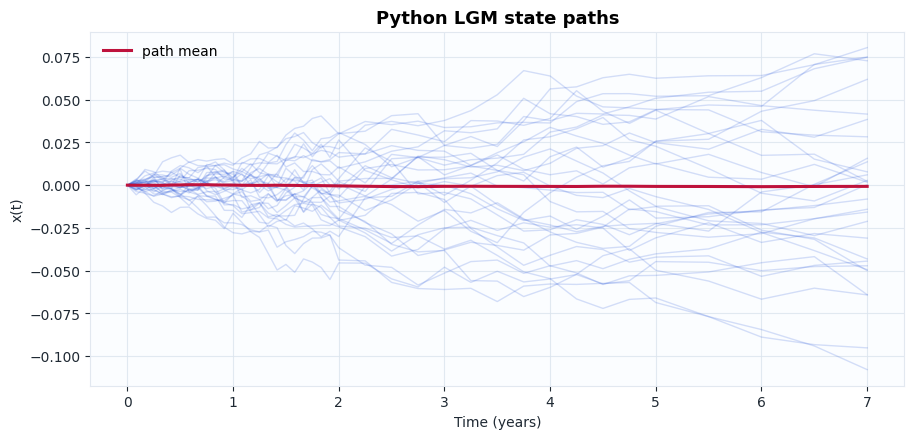

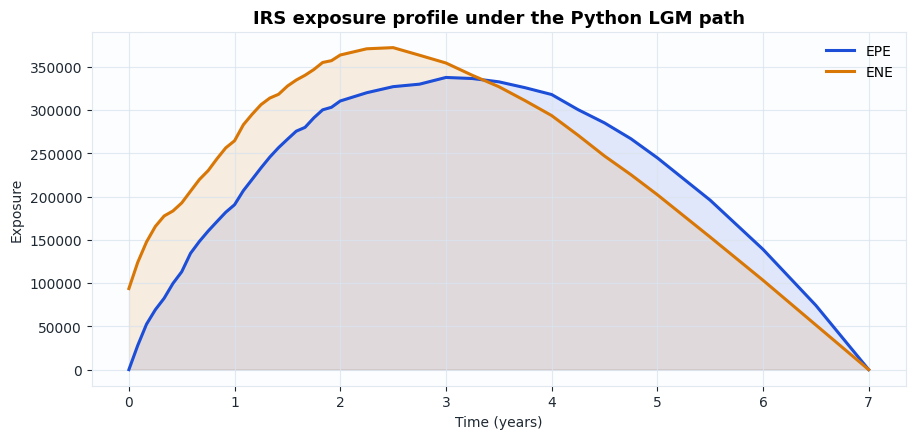

In [8]:
# Show the simulated state first, then the exposure profile derived from it.
nh.plot_lgm_paths(demo["times"], demo["x_paths"], max_paths=30, title="Python LGM state paths")
nh.plot_exposure_profile(
    demo["times"],
    demo["exposure"]["epe"],
    demo["exposure"]["ene"],
    title="IRS exposure profile under the Python LGM path",
)


The first figure is the latent state process. The second is the economic object that matters for XVA. Keeping both in
the notebook helps explain where differences later come from when engines disagree.


,scenario,par_rate,fixed_rate,CVA,DVA,FVA,XVA_TOTAL
0,USD-like IRS,0.031241,0.032741,15509.442526,12648.154821,6872.601122,9733.888827
1,EUR-like IRS,0.026741,0.028241,12717.742871,9865.560761,5910.436965,7884.449950


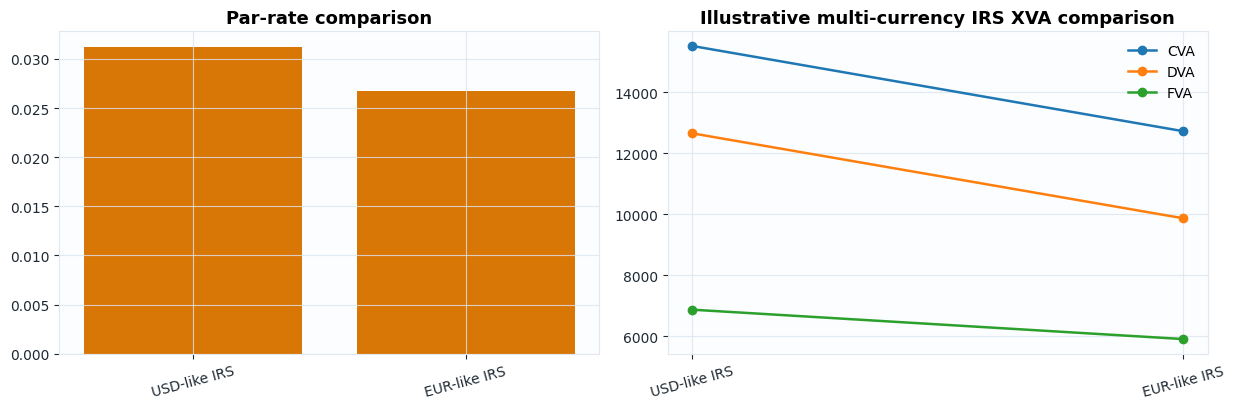

In [9]:
currency_compare = pd.DataFrame(
    [
        {"scenario": "USD-like IRS", "par_rate": usd_demo["par_rate"], "fixed_rate": usd_demo["fixed_rate"], **usd_demo["metrics"]},
        {"scenario": "EUR-like IRS", "par_rate": eur_demo["par_rate"], "fixed_rate": eur_demo["fixed_rate"], **eur_demo["metrics"]},
    ]
)
display(currency_compare)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
axes[0].bar(currency_compare["scenario"], currency_compare["par_rate"], color=nh.PALETTE["gold"])
axes[0].set_title("Par-rate comparison")
axes[0].tick_params(axis="x", rotation=15)

xva_compare = currency_compare.melt(
    id_vars=["scenario"],
    value_vars=["CVA", "DVA", "FVA"],
    var_name="metric",
    value_name="value",
)
for metric, grp in xva_compare.groupby("metric"):
    axes[1].plot(grp["scenario"], grp["value"], marker="o", linewidth=1.8, label=metric)
axes[1].set_title("Illustrative multi-currency IRS XVA comparison")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend()
plt.tight_layout()
plt.show()
plt.close(fig)


The older IRS demo was useful because it compared more than one market setup with the same runner. This section keeps
that idea, but uses it as an interpretive comparison rather than a second full notebook inside the notebook.


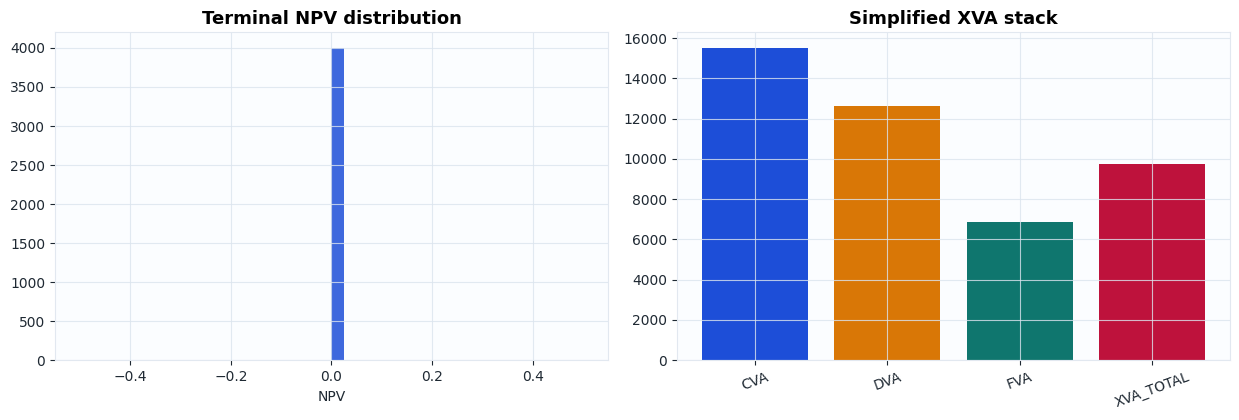

In [10]:
terminal_npv = demo["npv_paths"][-1]
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))
axes[0].hist(terminal_npv, bins=40, color=nh.PALETTE["blue"], alpha=0.85)
axes[0].set_title("Terminal NPV distribution")
axes[0].set_xlabel("NPV")

axes[1].bar(metric_df["metric"], metric_df["value"], color=[nh.PALETTE["blue"], nh.PALETTE["gold"], nh.PALETTE["teal"], nh.PALETTE["rose"]])
axes[1].set_title("Simplified XVA stack")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()
plt.close(fig)


## Sensitivity and runtime feel

The goal is not to turn this notebook into a performance study. A small two-point path-count check is enough to show
that the Python path is interactive and reasonably stable for exploratory work.


,paths,elapsed_sec,cva,fva
0,1000,0.020472,16398.568060,7272.460869
1,4000,0.041121,15509.442526,6872.601122


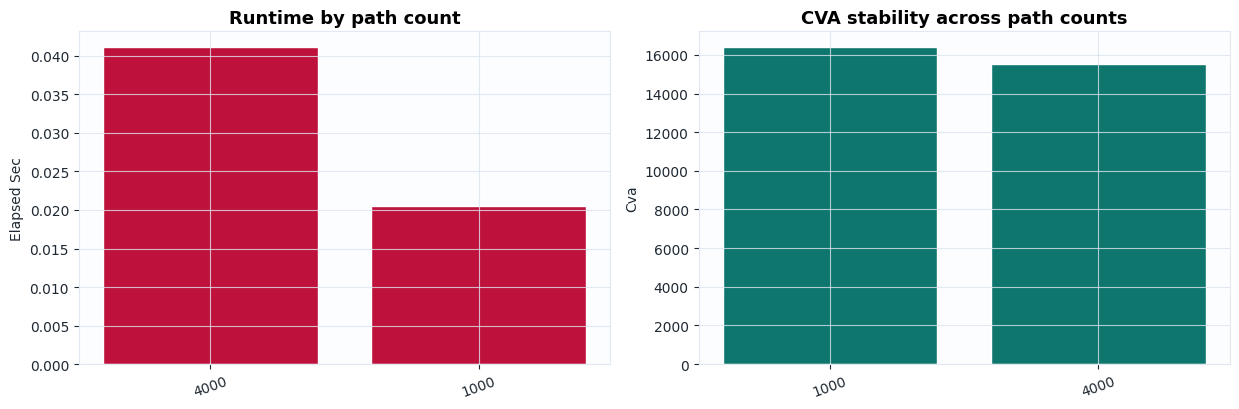

In [11]:
import time

runtime_rows = []
for n_paths in (1000, 4000):
    start = time.perf_counter()
    run = nh.run_python_lgm_demo(seed=42, n_paths=n_paths)
    elapsed = time.perf_counter() - start
    runtime_rows.append(
        {
            "paths": n_paths,
            "elapsed_sec": elapsed,
            "cva": run["metrics"]["CVA"],
            "fva": run["metrics"]["FVA"],
        }
    )

runtime_df = pd.DataFrame(runtime_rows)
display(runtime_df)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
nh.plot_bar_frame(runtime_df, "paths", "elapsed_sec", title="Runtime by path count", color=nh.PALETTE["rose"], ax=axes[0])
nh.plot_bar_frame(runtime_df, "paths", "cva", title="CVA stability across path counts", color=nh.PALETTE["teal"], ax=axes[1])
plt.tight_layout()
plt.show()
plt.close(fig)


,measure,n_paths,mean_sec,std_sec,min_sec,path_steps_per_sec
0,lgm,2000,0.000607,0.000060,0.000551,1.317353e+08
1,ba,2000,0.005496,0.000023,0.005469,1.455531e+07
2,lgm,10000,0.002384,0.000127,0.002266,1.677989e+08
3,ba,10000,0.009424,0.000091,0.009298,4.244676e+07


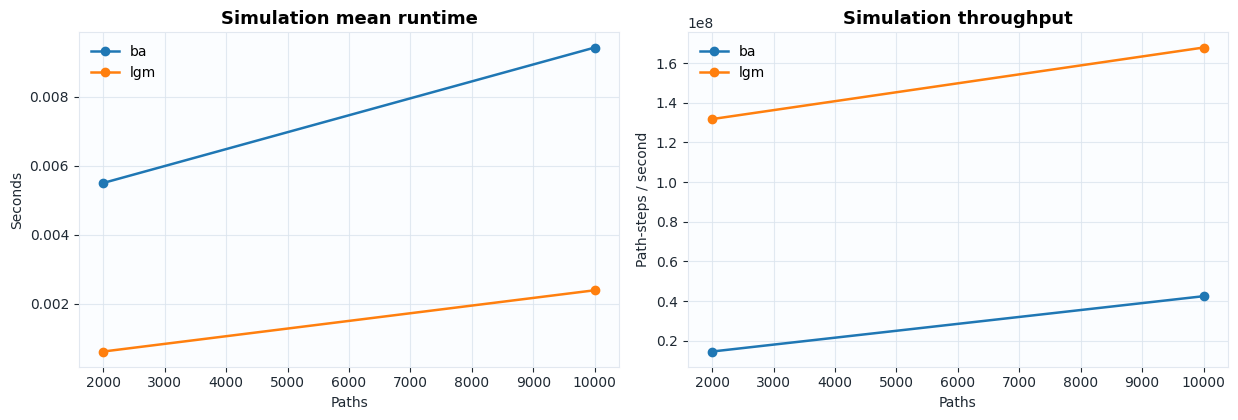

In [12]:
perf_bench_df = nh.lgm_benchmark_frame(demo["model"], demo["times"], path_counts=(2000, 10000), repeats=3, warmup=1)
display(perf_bench_df)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))
for measure, grp in perf_bench_df.groupby("measure"):
    axes[0].plot(grp["n_paths"], grp["mean_sec"], marker="o", linewidth=1.8, label=measure)
    axes[1].plot(grp["n_paths"], grp["path_steps_per_sec"], marker="o", linewidth=1.8, label=measure)
axes[0].set_title("Simulation mean runtime")
axes[0].set_xlabel("Paths")
axes[0].set_ylabel("Seconds")
axes[0].legend()

axes[1].set_title("Simulation throughput")
axes[1].set_xlabel("Paths")
axes[1].set_ylabel("Path-steps / second")
axes[1].legend()
plt.tight_layout()
plt.show()
plt.close(fig)


This benchmarking block is the missing piece from the old performance notebook. It is more informative than a single
elapsed time because it shows variance across runs and the throughput difference between the LGM and BA measures.


## Key takeaways

- The Python LGM path is transparent enough for notebook-level debugging and explanation.
- The exposure profile is the real driver of the XVA stack; the final metrics are only a summary layer.
- A small multi-scenario comparison helps show how the same runner behaves under different market regimes.
- Repeated benchmark runs with throughput are a better performance demo than one elapsed-time printout.
- This is the right baseline to carry into the joint Python-and-ORE notebook.

## Where this connects next

The final notebook puts Python and ORE side by side on a shared workflow and separates clean parity cases from live demos.
